# A guide Portfolio Optimization Environment

This notebook aims to provide an example of using PortfolioOptimizationEnv (or POE) to train a reinforcement learning model that learns to solve the portfolio optimization problem.

In this document, we will reproduce a famous architecture called EIIE (ensemble of identical independent evaluators), introduced in the following paper:

- Zhengyao Jiang, Dixing Xu, & Jinjun Liang. (2017). A Deep Reinforcement Learning Framework for the Financial Portfolio Management Problem. https://doi.org/10.48550/arXiv.1706.10059.

It's advisable to read it to understand the algorithm implemented in this notebook.

### Note
If you're using this environment, consider citing the following paper (in adittion to FinRL references):

- Caio Costa, & Anna Costa (2023). POE: A General Portfolio Optimization Environment for FinRL. In *Anais do II Brazilian Workshop on Artificial Intelligence in Finance* (pp. 132–143). SBC. https://doi.org/10.5753/bwaif.2023.231144.

```
@inproceedings{bwaif,
 author = {Caio Costa and Anna Costa},
 title = {POE: A General Portfolio Optimization Environment for FinRL},
 booktitle = {Anais do II Brazilian Workshop on Artificial Intelligence in Finance},
 location = {João Pessoa/PB},
 year = {2023},
 keywords = {},
 issn = {0000-0000},
 pages = {132--143},
 publisher = {SBC},
 address = {Porto Alegre, RS, Brasil},
 doi = {10.5753/bwaif.2023.231144},
 url = {https://sol.sbc.org.br/index.php/bwaif/article/view/24959}
}

```

## Installation and imports

To run this notebook in google colab, uncomment the cells below.

In [41]:
## install finrl library
# !sudo apt install swig
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

In [42]:
## We also need to install quantstats, because the environment uses it to plot graphs
# !pip install quantstats

In [1]:
## Hide matplotlib warnings
# import warnings
# warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

#### Import the necessary code libraries

In [2]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

## Fetch data

In his paper, *Jiang et al* creates a portfolio composed by the top-11 cryptocurrencies based on 30-days volume. Since it's not specified when this classification was done, it's difficult to reproduce, so we will use a similar approach in the Brazillian stock market:

- We select top-10 stocks from Brazillian stock market;
- For simplicity, we disconsider stocks that have missing data for the days in period 2011-01-01 to 2019-12-31 (9 years);

In [104]:
TOP_BRL = [
'2777.hk','1918.hk','9979.hk','0700.hk','1810.hk','1812.hk'
]

In [105]:
print(len(TOP_BRL))

portfolio_raw_df = YahooDownloader(start_date = '2021-01-01',
                                end_date = '2025-01-15',
                                ticker_list = TOP_BRL).fetch_data()
portfolio_raw_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

6
Shape of DataFrame:  (5946, 8)


,date,open,high,low,close,volume,tic,day
0,2021-01-04,514.395874,537.442322,513.934998,515.461853,22545919,0700.hk,0
1,2021-01-04,33.599998,35.400002,33.250000,35.250000,231688252,1810.hk,0
2,2021-01-04,3.770000,4.180000,3.770000,3.917133,19428000,1812.hk,0
3,2021-01-04,28.250000,28.500000,26.450001,24.658558,41277820,1918.hk,0
4,2021-01-04,9.970000,9.980000,9.590000,8.849035,5848234,2777.hk,0
...,...,...,...,...,...,...,...,...
5941,2025-01-14,32.750000,34.150002,32.750000,33.750000,122182323,1810.hk,1
5942,2025-01-14,1.120000,1.150000,1.120000,1.150000,1755000,1812.hk,1
5943,2025-01-14,1.490000,1.570000,1.450000,1.540000,396861547,1918.hk,1
5944,2025-01-14,1.220000,1.270000,1.220000,1.270000,12177163,2777.hk,1


In [106]:
portfolio_raw_df.groupby("tic").count()

,date,open,high,low,close,volume,day
tic,,,,,,,
0700.hk,991,991,991,991,991,991,991
1810.hk,991,991,991,991,991,991,991
1812.hk,991,991,991,991,991,991,991
1918.hk,991,991,991,991,991,991,991
2777.hk,991,991,991,991,991,991,991
9979.hk,991,991,991,991,991,991,991


### Normalize Data

We normalize the data dividing the time series of each stock by its maximum value, so that the dataframe contains values between 0 and 1.

In [107]:
portfolio_norm_df = GroupByScaler(by="tic", scaler=MaxAbsScaler).fit_transform(portfolio_raw_df)
portfolio_norm_df

,date,open,high,low,close,volume,tic,day
0,2021-01-04,0.727510,0.751773,0.736460,0.746901,0.084015,0700.hk,0.00
1,2021-01-04,0.932039,0.960651,0.932679,0.971074,0.201599,1810.hk,0.00
2,2021-01-04,0.407568,0.422222,0.438372,0.443243,0.254824,1812.hk,0.00
3,2021-01-04,0.809456,0.793872,0.782544,0.779856,0.013294,1918.hk,0.00
4,2021-01-04,0.931776,0.927509,0.906427,0.910112,0.021864,2777.hk,0.00
...,...,...,...,...,...,...,...,...
5941,2025-01-14,0.908460,0.926730,0.918654,0.929752,0.106315,1810.hk,0.25
5942,2025-01-14,0.121081,0.116162,0.130233,0.130128,0.023019,1812.hk,0.25
5943,2025-01-14,0.042693,0.043733,0.042899,0.048704,0.127811,1918.hk,0.25
5944,2025-01-14,0.114019,0.118030,0.115312,0.130618,0.045526,2777.hk,0.25


In [121]:
df_portfolio = portfolio_norm_df[["date", "tic", "close", "high", "low"]]

df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2022-01-01") & (df_portfolio["date"] < "2025-01-12")]

df_portfolio = df_portfolio[(df_portfolio["date"] >= "2024-01-01") & (df_portfolio["date"] <= "2025-01-14")]

### Instantiate Environment

Using the `PortfolioOptimizationEnv`, it's easy to instantiate a portfolio optimization environment for reinforcement learning agents. In the example below, we use the dataframe created before to start an environment.

In [124]:
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=50,
        features=["close", "high", "low"],
        normalize_df=None
    )

### Instantiate Model

Now, we can instantiate the model using FinRL API. In this example, we are going to use the EIIE architecture introduced by Jiang et. al.

:exclamation: **Note:** Remember to set the architecture's `time_window` parameter with the same value of the environment's `time_window`.

In [126]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": 0.01,
    "policy": EIIE,
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": 3,
    "time_window": 50,
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)
model.load_state_dict(torch.load("policy_EIIE.pt"))

AttributeError: 'PolicyGradient' object has no attribute 'load_state_dict'

### Train Model

In [111]:
DRLAgent.train_model(model, episodes=140)

  0%|          | 0/140 [00:00<?, ?it/s]

Initial portfolio value:100000
Final portfolio value: 98970.9609375
Final accumulative portfolio value: 0.989709609375
Maximum DrawDown: -0.38123722268493976
Sharpe ratio: 0.18686167703898582


  1%|          | 1/140 [00:02<05:54,  2.55s/it]

Initial portfolio value:100000
Final portfolio value: 99694.6875
Final accumulative portfolio value: 0.996946875
Maximum DrawDown: -0.3765607180933018
Sharpe ratio: 0.1921833587098652


  1%|▏         | 2/140 [00:04<05:41,  2.47s/it]

...

 99%|█████████▊| 138/140 [05:37<00:04,  2.40s/it]

Initial portfolio value:100000
Final portfolio value: 3684826.75
Final accumulative portfolio value: 36.8482675
Maximum DrawDown: -0.21356697377347422
Sharpe ratio: 1.852258690201339


 99%|█████████▉| 139/140 [05:39<00:02,  2.43s/it]

Initial portfolio value:100000
Final portfolio value: 3215191.25
Final accumulative portfolio value: 32.1519125
Maximum DrawDown: -0.2409823323473379
Sharpe ratio: 1.7595820988896544


100%|██████████| 140/140 [05:41<00:00,  2.44s/it]


### Save Model

In [116]:
torch.save(model.train_policy.state_dict(), "policy_EIIE.pt")

## Test Model

### Instantiate different environments

Since we have three different periods of time, we need three different environments instantiated to simulate them.

In [117]:
policy = EIIE(time_window=50, device=device)
policy.load_state_dict(torch.load("policy_EIIE.pt"))
environment_2025 = PortfolioOptimizationEnv(
    df_portfolio,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)
# df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
#     model=model, 
#     environment = environment_2025)

# environment_2021 = PortfolioOptimizationEnv(
#     df_portfolio_2021,
#     initial_amount=100000,
#     comission_fee_pct=0.0025,
#     time_window=50,
#     features=["close", "high", "low"],
#     normalize_df=None
# )

# environment_2022 = PortfolioOptimizationEnv(
#     df_portfolio_2022,
#     initial_amount=100000,
#     comission_fee_pct=0.0025,
#     time_window=50,
#     features=["close", "high", "low"],
#     normalize_df=None
# )

### Test EIIE architecture
Now, we can test the EIIE architecture in the three different test periods. It's important no note that, in this code, we load the saved policy even though it's not necessary just to show how to save and load your model.

In [118]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2025": {},

}

# instantiate an architecture with the same arguments used in training
# and load with load_state_dict.
policy = EIIE(time_window=50, device=device)
policy.load_state_dict(torch.load("policy_EIIE.pt"))

# 2020
DRLAgent.DRL_validation(model, environment_2025, policy=policy)
EIIE_results["2025"]["value"] = environment_2025._asset_memory["final"]

# # 2021
# DRLAgent.DRL_validation(model, environment_2021, policy=policy)
# EIIE_results["2021"]["value"] = environment_2021._asset_memory["final"]

# # 2022
# DRLAgent.DRL_validation(model, environment_2022, policy=policy)
# EIIE_results["2022"]["value"] = environment_2022._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 100000.0
Final accumulative portfolio value: 1.0
Maximum DrawDown: 0.0
Sharpe ratio: nan


/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/quantstats/stats.py:294: RuntimeWarning: invalid value encountered in scalar divide
  res = returns.mean() / divisor


In [120]:
for i, action in enumerate(environment_2025._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        print(f"Action at step {i}: {action}")

Action at step 0: [1. 0. 0. 0. 0. 0. 0.]
Action at step 1: [1.0000000e+00 0.0000000e+00 0.0000000e+00 1.4433374e-43 1.2106788e-15
 0.0000000e+00 0.0000000e+00]
Action at step 2: [1.0000000e+00 0.0000000e+00 0.0000000e+00 7.2447131e-43 1.1485062e-15
 1.4012985e-45 0.0000000e+00]
Action at step 3: [1.00000e+00 0.00000e+00 0.00000e+00 2.24908e-42 9.45644e-16 1.40130e-45
 0.00000e+00]
Action at step 4: [1.0000000e+00 0.0000000e+00 0.0000000e+00 5.3613679e-42 6.4952694e-16
 2.8025969e-45 0.0000000e+00]
Action at step 5: [1.000000e+00 0.000000e+00 0.000000e+00 1.202034e-41 4.509245e-16
 4.203895e-45 0.000000e+00]
Action at step 6: [1.0000000e+00 0.0000000e+00 0.0000000e+00 2.9095160e-41 3.8584773e-16
 7.0064923e-45 0.0000000e+00]
Action at step 7: [1.00000e+00 0.00000e+00 0.00000e+00 6.48002e-41 5.06047e-16 2.52234e-44
 0.00000e+00]
Action at step 8: [1.0000000e+00 0.0000000e+00 0.0000000e+00 9.3666993e-41 8.3885585e-16
 1.0509738e-43 0.0000000e+00]
Action at step 9: [1.0000000e+00 0.0000000

### Test Uniform Buy and Hold
For comparison, we will also test the performance of a uniform buy and hold strategy. In this strategy, the portfolio has no remaining cash and the same percentage of money is allocated in each asset.

In [54]:
UBAH_results = {
    "train": {},
    "2025": {},
    # "2021": {},
    # "2022": {}
}

PORTFOLIO_SIZE = len(TOP_BRL)

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]

# 2020
terminated = False
environment_2025.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2025.step(action)
UBAH_results["2025"]["value"] = environment_2025._asset_memory["final"]

# # 2021
# terminated = False
# environment_2021.reset()
# while not terminated:
#     action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
#     _, _, terminated, _ = environment_2021.step(action)
# UBAH_results["2021"]["value"] = environment_2021._asset_memory["final"]

# # 2022
# terminated = False
# environment_2022.reset()
# while not terminated:
#     action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
#     _, _, terminated, _ = environment_2022.step(action)
# UBAH_results["2022"]["value"] = environment_2022._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 71258.3125
Final accumulative portfolio value: 0.712583125
Maximum DrawDown: -0.6791984908065596
Sharpe ratio: 0.07982901637304428
Initial portfolio value:100000
Final portfolio value: 106720.71875
Final accumulative portfolio value: 1.0672071875
Maximum DrawDown: -0.46812625377421013
Sharpe ratio: 0.4403333031023637


### Plot graphics

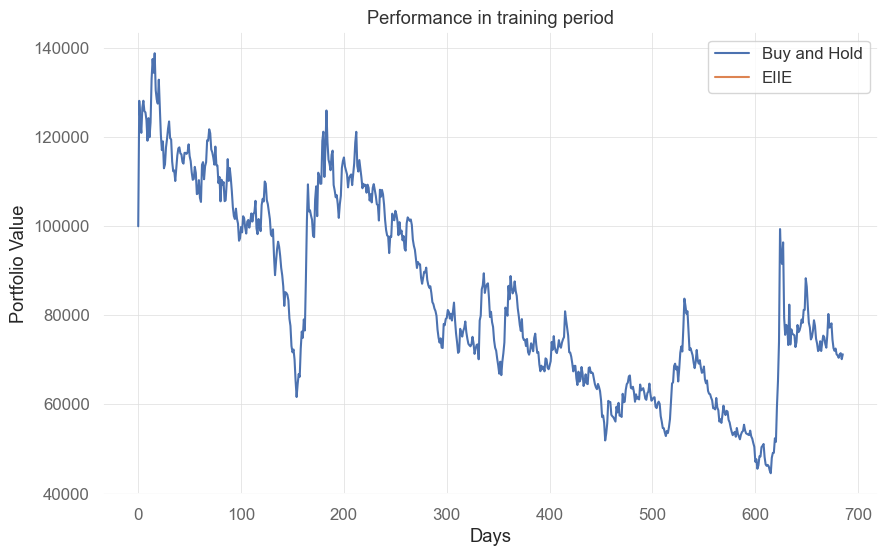

In [55]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["training"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()

plt.show()

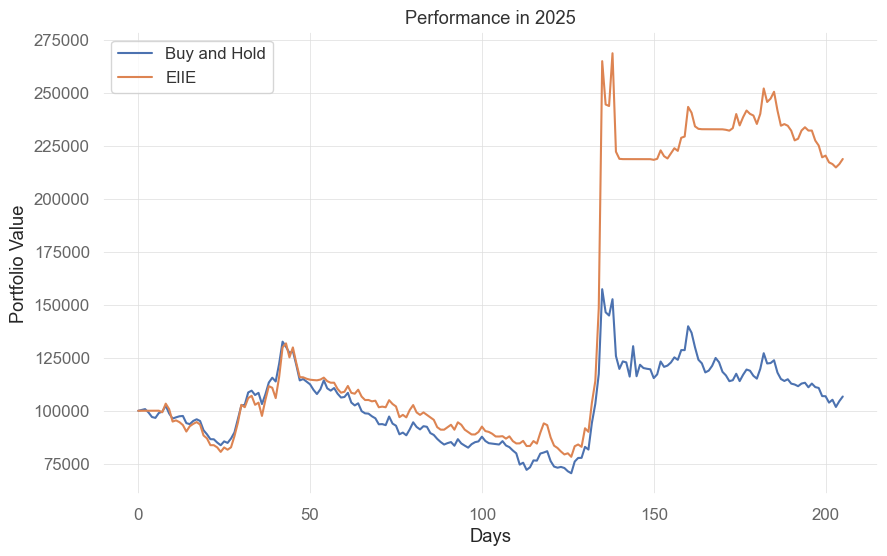

In [56]:
plt.plot(UBAH_results["2025"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2025"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2025")
plt.legend()

plt.show()

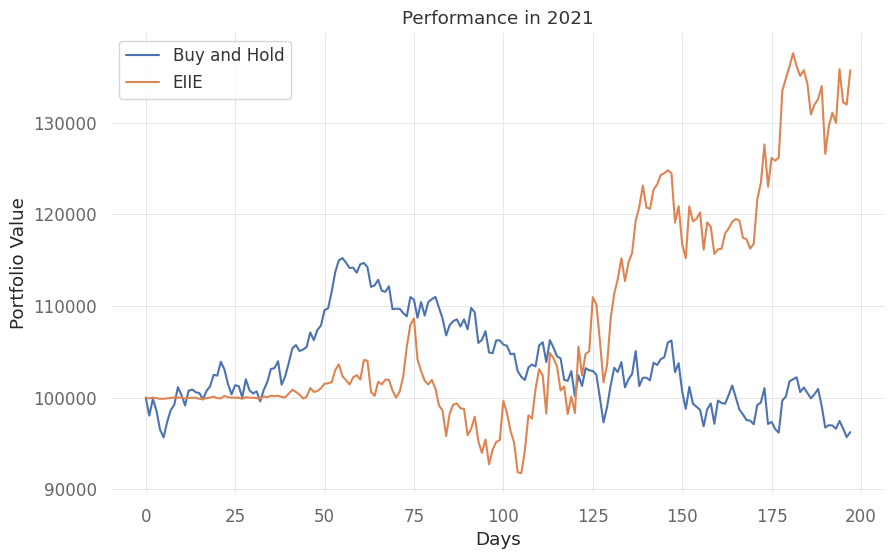

In [59]:
plt.plot(UBAH_results["2021"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2021"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2021")
plt.legend()

plt.show()

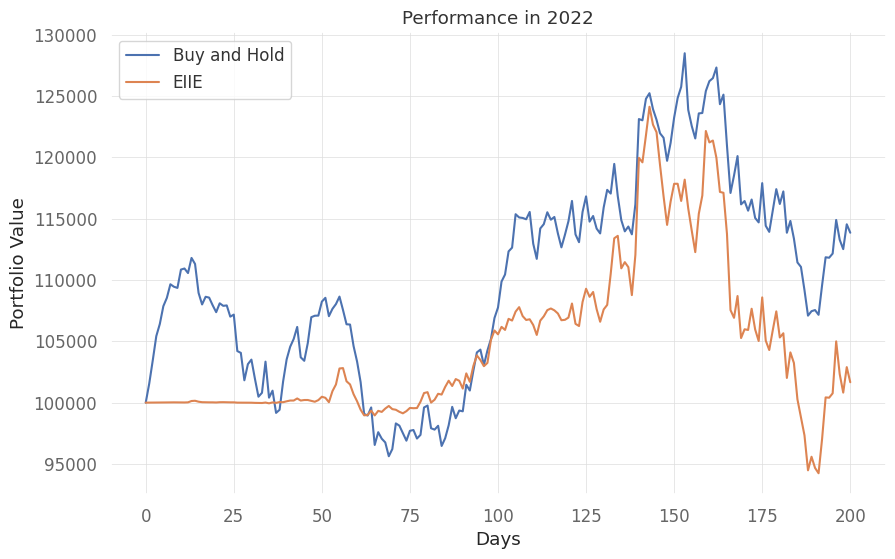

In [60]:
plt.plot(UBAH_results["2022"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2022"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2022")
plt.legend()

plt.show()

We can see that the agent is able to learn a good policy but its performance is worse the more the test period advances into the future. To get a better performance in 2022, for example, the agent should probably be trained again using more recent data.